In [1]:
import MotifCompendium
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"


In [2]:
MotifCompendium.set_compute_options(max_cpus=4, progress_bar=True, max_chunk=1152, use_gpu=True)

In [8]:
maindir = "/oak/stanford/groups/akundaje/projects/chromatin-atlas-2022/chrombpnet/folds/ATAC/"
modisco_dict = {
    "GM12878": maindir+"GM12878/merge_folds_new_may_05_24/profile/modisco_profile.h5",
    "K562": maindir+"K562/merge_folds_new_may_05_24/profile/modisco_profile.h5",
     "HEPG2": maindir+"HEPG2/merge_folds_new_may_05_24/profile/modisco_profile.h5",
     "IMR90": maindir+"IMR90/merge_folds_new_may_05_24/profile/modisco_profile.h5",
     "H1ESC": maindir+"H1ESC/merge_folds_new_may_05_24/profile/modisco_profile.h5",    
}
mc = MotifCompendium.build_from_modisco(modisco_dict, modisco_region_width=500)
mc

computing similarities on GPU...: 100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 16.55it/s]


,name,num_seqlets,model,posneg,avg_contrib,avg_dist_from_summit
0,GM12878-pos.pattern_0,41115,GM12878,pos,0.315399,29.851003
1,GM12878-pos.pattern_1,38163,GM12878,pos,0.065738,56.056128
2,GM12878-pos.pattern_10,3274,GM12878,pos,0.049050,61.050703
3,GM12878-pos.pattern_11,3004,GM12878,pos,0.041959,52.051931
4,GM12878-pos.pattern_12,2739,GM12878,pos,0.073095,57.560789
...,...,...,...,...,...,...
535,H1ESC-neg.pattern_5,228,H1ESC,neg,-0.018731,54.750000
536,H1ESC-neg.pattern_6,203,H1ESC,neg,-0.028653,106.541872
537,H1ESC-neg.pattern_7,151,H1ESC,neg,-0.019478,81.099338
538,H1ESC-neg.pattern_8,137,H1ESC,neg,0.016568,58.036496


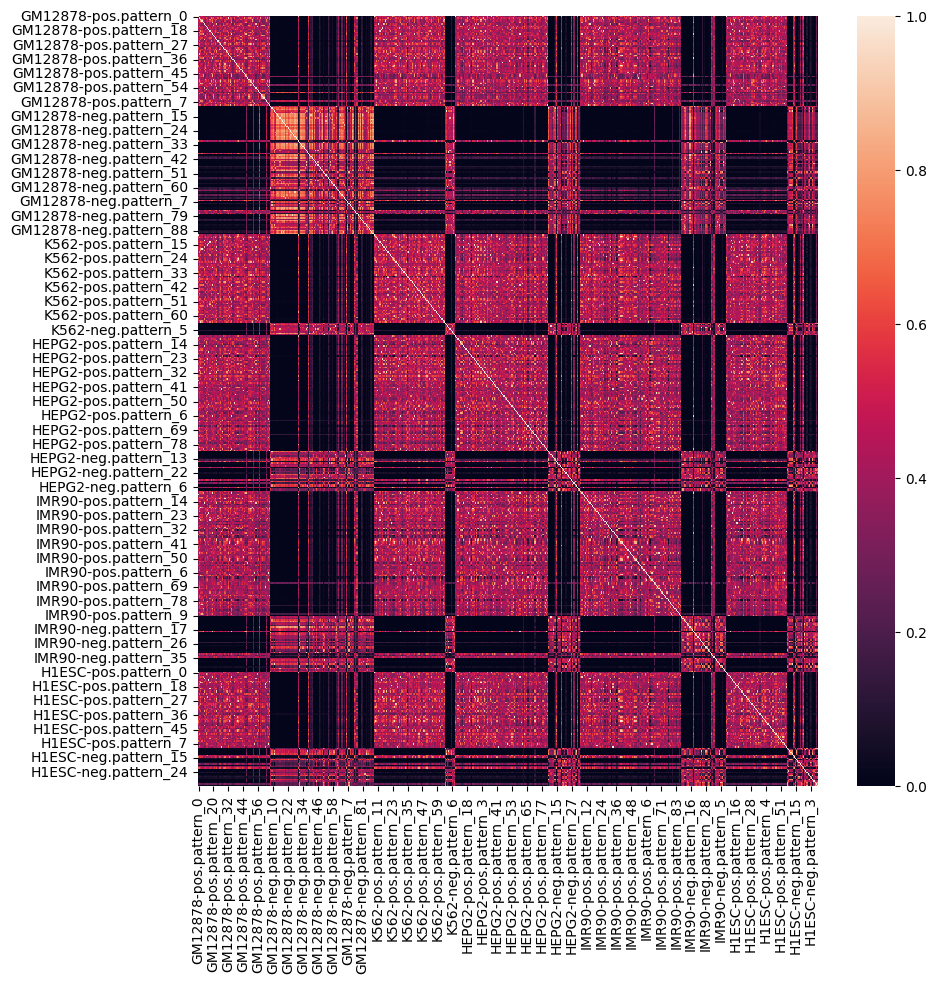

In [9]:
mc.heatmap(show=True, label=True)

In [10]:
import MotifCompendium.utils.analysis as utils_analysis

In [11]:
utils_analysis.plot_similarity_distribution(
    mc, "chrombpnet_outputs_profile/similarity_distribution.html"
)

In [12]:
mc.cluster(similarity_threshold=0.97)
mc

,name,num_seqlets,model,posneg,avg_contrib,avg_dist_from_summit,cluster
0,GM12878-pos.pattern_0,41115,GM12878,pos,0.315399,29.851003,3
1,GM12878-pos.pattern_1,38163,GM12878,pos,0.065738,56.056128,398
2,GM12878-pos.pattern_10,3274,GM12878,pos,0.049050,61.050703,17
3,GM12878-pos.pattern_11,3004,GM12878,pos,0.041959,52.051931,44
4,GM12878-pos.pattern_12,2739,GM12878,pos,0.073095,57.560789,154
...,...,...,...,...,...,...,...
535,H1ESC-neg.pattern_5,228,H1ESC,neg,-0.018731,54.750000,160
536,H1ESC-neg.pattern_6,203,H1ESC,neg,-0.028653,106.541872,159
537,H1ESC-neg.pattern_7,151,H1ESC,neg,-0.019478,81.099338,158
538,H1ESC-neg.pattern_8,137,H1ESC,neg,0.016568,58.036496,157


In [13]:
# len(set(mc['cluster']))
# 574 clusters

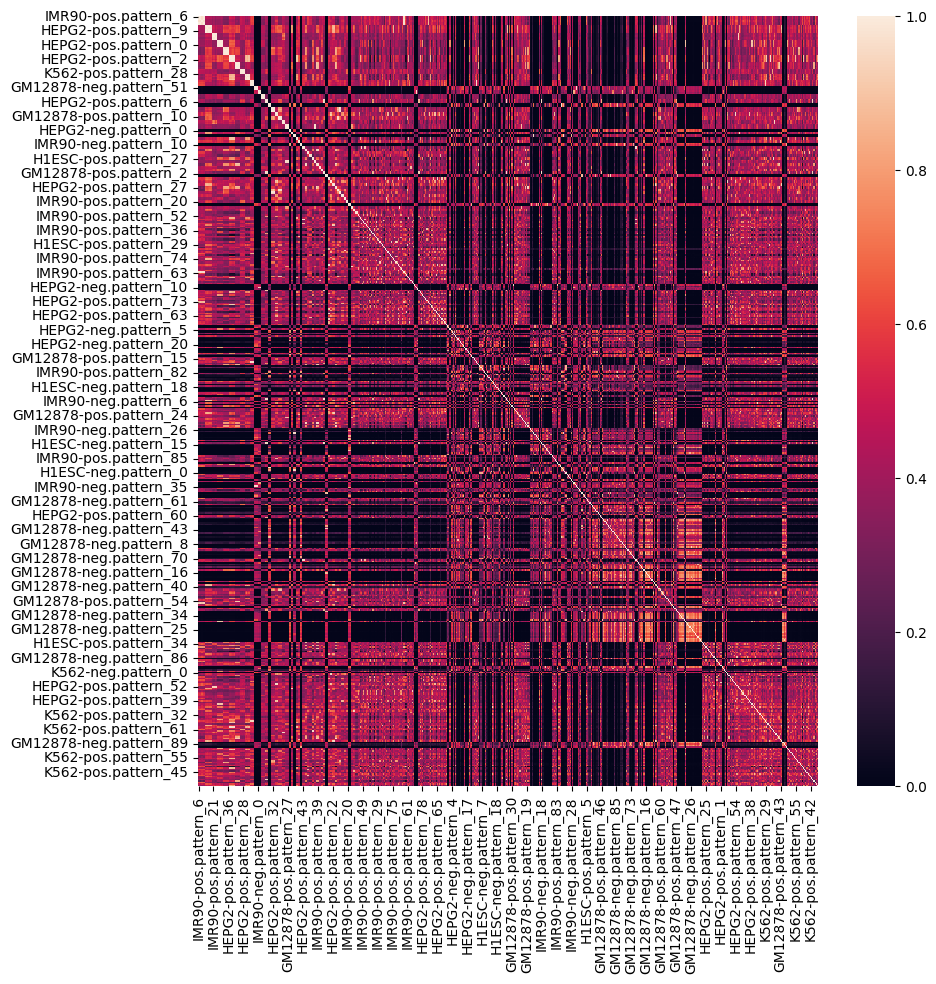

In [14]:
mc.sort(by="cluster").heatmap(show=True, label=True)

In [15]:
mc.motif_collection_html("chrombpnet_outputs_counts/motif_collection.html", "cluster")

In [16]:
mc

,name,num_seqlets,model,posneg,avg_contrib,avg_dist_from_summit,cluster
0,GM12878-pos.pattern_0,41115,GM12878,pos,0.315399,29.851003,3
1,GM12878-pos.pattern_1,38163,GM12878,pos,0.065738,56.056128,398
2,GM12878-pos.pattern_10,3274,GM12878,pos,0.049050,61.050703,17
3,GM12878-pos.pattern_11,3004,GM12878,pos,0.041959,52.051931,44
4,GM12878-pos.pattern_12,2739,GM12878,pos,0.073095,57.560789,154
...,...,...,...,...,...,...,...
535,H1ESC-neg.pattern_5,228,H1ESC,neg,-0.018731,54.750000,160
536,H1ESC-neg.pattern_6,203,H1ESC,neg,-0.028653,106.541872,159
537,H1ESC-neg.pattern_7,151,H1ESC,neg,-0.019478,81.099338,158
538,H1ESC-neg.pattern_8,137,H1ESC,neg,0.016568,58.036496,157


In [ ]:
mc_avg = mc.cluster_averages("cluster")
mc_avg

In [14]:
mc_avg = mc.cluster_averages("cluster")
mc_avg

computing similarities on GPU...: 100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 69.97it/s]


,name,source_cluster,num_constituents
0,cluster#0,0,5
1,cluster#1,1,5
2,cluster#2,2,5
3,cluster#3,3,5
4,cluster#4,4,5
...,...,...,...
222,cluster#222,222,1
223,cluster#223,223,1
224,cluster#224,224,1
225,cluster#225,225,1


In [16]:
mc.save("chrombpnet_outputs_counts/motif_compendium.mc")
mc_avg.save("chrombpnet_outputs_counts/motif_compendium_average.mc")

In [31]:
mc_avg.summary_table_html("chrombpnet_outputs_counts/cluster_summary_table.html")

In [45]:
output_path= "/oak/stanford/groups/akundaje/cmyun/motifcompendium/tfatlas/encode/pipeline/counts/pipeline_counts_intarget-0.88-meta0.88-rec-force0.92/motifcompendium_avg_filtered.mc"

mc_3 = MotifCompendium.load(output_path, safe=True)


In [32]:
mc.save("chrombpnet_outputs/motif_compendium.mc")
mc_avg.save("chrombpnet_outputs/motif_compendium_average.mc")